# FoG Labeling from EAF annotations

This notebook labels all IMU devices directly from an ELAN `.eaf` annotation file.

**Input:**
- `recording_data.h5` — IMU data + camera timestamps
- `task_circuit8_FOG002.eaf` — ELAN annotations (FoG episodes + Tasks)

**Output:** one CSV per device with columns:
`timestamp_lsl | acc_x | acc_y | acc_z | quat_w | quat_x | quat_y | quat_z | fog_label | task_label`

**Key:** EAF timestamps are in **milliseconds from video start**.
Camera frame 0 in the H5 gives us the LSL timestamp of video start → conversion is straightforward.

## 1. Imports

In [22]:
import h5py
import numpy as np
import pandas as pd
import xml.etree.ElementTree as ET
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

## 2. Parameters

In [23]:
import os

PATH_H5  = 'recording_data.h5'
PATH_EAF = 'task_stop_FOG002.eaf'
CAMERA   = 'camera_1'   # camera used as time reference
DEVICES  = ['dev2', 'dev3', 'dev5', 'dev6', 'dev7']
SIGNAL_COLS = ['acc_x', 'acc_y', 'acc_z', 'quat_w', 'quat_x', 'quat_y', 'quat_z']

# Session name extracted automatically from EAF filename
# e.g. 'task_stop_FOG002.eaf' -> SESSION_NAME = 'task_stop_FOG002'
SESSION_NAME = os.path.splitext(os.path.basename(PATH_EAF))[0]
print(f'Session name: {SESSION_NAME}')
print(f'Output files will be named: IMU_devX_{SESSION_NAME}_labeled.csv')

Session name: task_stop_FOG002
Output files will be named: IMU_devX_task_stop_FOG002_labeled.csv


## 3. Parse the EAF file
Extract all FOG episodes and Task annotations with their start/end times in milliseconds.

In [24]:
def parse_eaf(path):
    """
    Parse an ELAN .eaf file.
    Returns:
      - time_slots: dict {TIME_SLOT_ID -> TIME_VALUE in ms}
      - fog_events: list of (start_ms, end_ms)
      - task_events: list of (start_ms, end_ms, task_label)
    """
    tree = ET.parse(path)
    root = tree.getroot()

    # Build time slot lookup
    time_slots = {}
    for ts in root.find('TIME_ORDER').findall('TIME_SLOT'):
        time_slots[ts.attrib['TIME_SLOT_ID']] = int(ts.attrib['TIME_VALUE'])

    fog_events  = []
    task_events = []

    for tier in root.findall('TIER'):
        tier_id = tier.attrib.get('TIER_ID', '')

        for ann in tier.findall('.//ALIGNABLE_ANNOTATION'):
            t1 = time_slots[ann.attrib['TIME_SLOT_REF1']]
            t2 = time_slots[ann.attrib['TIME_SLOT_REF2']]
            val = ann.find('ANNOTATION_VALUE').text

            if tier_id == 'FOG':
                fog_events.append((t1, t2))
            elif tier_id == 'Task':
                task_events.append((t1, t2, val))

    return time_slots, fog_events, task_events


_, fog_events, task_events = parse_eaf(PATH_EAF)

print(f"FOG episodes : {len(fog_events)}")
for s, e in fog_events:
    print(f"  {s/1000:.2f}s → {e/1000:.2f}s  (duration: {(e-s)/1000:.2f}s)")

print(f"\nTask annotations : {len(task_events)}")
for s, e, label in task_events:
    print(f"  {s/1000:.2f}s → {e/1000:.2f}s  [{label}]")

FOG episodes : 0

Task annotations : 10
  49.06s → 54.02s  [Stop]
  66.80s → 70.97s  [Stop]
  103.44s → 106.50s  [Stop]
  119.06s → 122.17s  [Stop]
  142.87s → 146.56s  [Stop]
  155.89s → 162.29s  [Stop]
  188.63s → 192.85s  [Stop]
  207.18s → 210.95s  [Stop]
  231.92s → 235.63s  [Stop]
  246.31s → 249.53s  [Stop]


## 4. Load camera timestamps from H5
The first camera frame gives us the LSL timestamp of t=0 in the video.

In [25]:
with h5py.File(PATH_H5, 'r') as f:
    cam_raw = f[f'Cameras/{CAMERA}/frames'][:]
    cam_ts  = cam_raw['timestamp']  # LSL timestamps

# t=0 in the video corresponds to the first camera frame LSL timestamp
t0_lsl = cam_ts[0]
print(f"Camera start (t=0 video) → LSL timestamp: {t0_lsl:.6f} s")
print(f"Camera duration: {cam_ts[-1] - cam_ts[0]:.1f} s ({len(cam_ts)} frames)")

Camera start (t=0 video) → LSL timestamp: 1210585.825606 s
Camera duration: 265.7 s (7924 frames)


## 5. Convert EAF times to LSL timestamps
`lsl_timestamp = t0_lsl + (eaf_time_ms / 1000.0)`

In [26]:
# Convert FOG events
fog_lsl = [(t0_lsl + s/1000.0, t0_lsl + e/1000.0) for s, e in fog_events]

# Convert Task events — build unique label list
task_labels_list = sorted(set(label for _, _, label in task_events))
task_label_map   = {label: i+1 for i, label in enumerate(task_labels_list)}
task_label_map['no_task'] = 0

task_lsl = [(t0_lsl + s/1000.0, t0_lsl + e/1000.0, label) for s, e, label in task_events]

print("FOG events in LSL time:")
for s, e in fog_lsl:
    print(f"  {s:.3f} → {e:.3f}  (duration: {e-s:.2f}s)")

print("\nTask label encoding:")
for label, code in task_label_map.items():
    print(f"  {code}: {label}")

FOG events in LSL time:

Task label encoding:
  1: Stop
  0: no_task


## 6. Load IMU data and generate labels

In [27]:
with h5py.File(PATH_H5, 'r') as f:
    imu = {}
    for dev in DEVICES:
        imu[dev] = {
            'timestamps': f[f'WIMU/WIMU_MK3/timestamps_{dev}'][:],
            'data':       f[f'WIMU/WIMU_MK3/data_{dev}'][:]
        }

for dev in DEVICES:
    imu_ts   = imu[dev]['timestamps']
    imu_data = imu[dev]['data']

    # --- FOG label (binary) ---
    fog_labels = np.zeros(len(imu_ts), dtype=int)
    for t_start, t_end in fog_lsl:
        fog_labels[(imu_ts >= t_start) & (imu_ts <= t_end)] = 1

    # --- Task label (categorical) ---
    task_labels = np.zeros(len(imu_ts), dtype=int)  # 0 = no task
    for t_start, t_end, label in task_lsl:
        code = task_label_map.get(label, 0)
        task_labels[(imu_ts >= t_start) & (imu_ts <= t_end)] = code

    # --- Build DataFrame ---
    df = pd.DataFrame(imu_data, columns=['timestamp_imu'] + SIGNAL_COLS)
    df.insert(0, 'timestamp_lsl', imu_ts)
    df['fog_label']  = fog_labels
    df['task_label'] = task_labels

    output_path = f'IMU_{dev}_{SESSION_NAME}_labeled.csv'
    df.to_csv(output_path, index=False)

    print(f"{dev} -> {fog_labels.sum()} FOG samples ({100*fog_labels.mean():.1f}%) | saved: {output_path}")

# Save task label encoding for reference
pd.DataFrame(list(task_label_map.items()), columns=['task', 'code']).to_csv(f'task_label_encoding_{SESSION_NAME}.csv', index=False)
print(f"\nTask encoding saved: task_label_encoding_{SESSION_NAME}.csv")

dev2 -> 0 FOG samples (0.0%) | saved: IMU_dev2_task_stop_FOG002_labeled.csv
dev3 -> 0 FOG samples (0.0%) | saved: IMU_dev3_task_stop_FOG002_labeled.csv
dev5 -> 0 FOG samples (0.0%) | saved: IMU_dev5_task_stop_FOG002_labeled.csv
dev6 -> 0 FOG samples (0.0%) | saved: IMU_dev6_task_stop_FOG002_labeled.csv
dev7 -> 0 FOG samples (0.0%) | saved: IMU_dev7_task_stop_FOG002_labeled.csv

Task encoding saved: task_label_encoding_task_stop_FOG002.csv


## 7. Visual verification

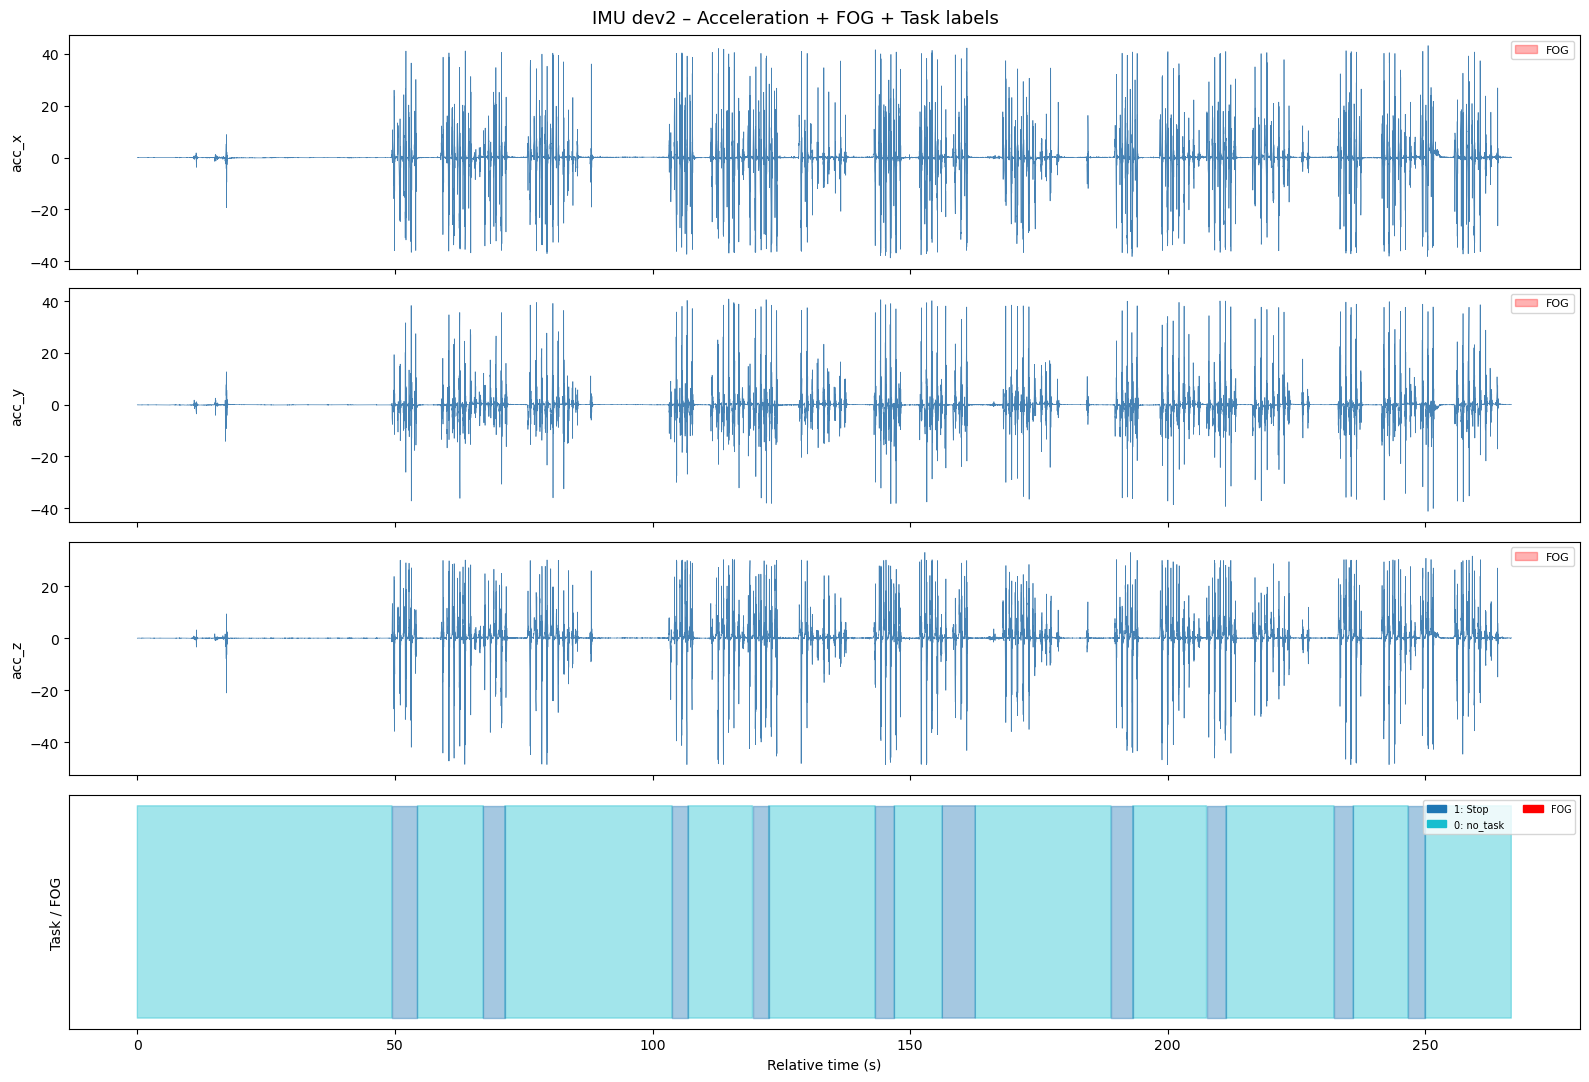

In [28]:
DEV_TO_PLOT = 'dev2'  # change to inspect another device

df  = pd.read_csv(f'IMU_{DEV_TO_PLOT}_{SESSION_NAME}_labeled.csv')
t   = df['timestamp_lsl'] - df['timestamp_lsl'].iloc[0]

# Color map for tasks
task_colors = plt.cm.tab10(np.linspace(0, 1, len(task_label_map)))
color_map   = {code: task_colors[i] for i, (_, code) in enumerate(task_label_map.items())}

fig, axes = plt.subplots(4, 1, figsize=(16, 11), sharex=True)

# Acceleration plots with FOG highlight
for ax, col in zip(axes[:3], ['acc_x', 'acc_y', 'acc_z']):
    ax.plot(t, df[col], linewidth=0.5, color='steelblue')
    ax.set_ylabel(col)
    ymin, ymax = df[col].min(), df[col].max()
    ax.fill_between(t, ymin, ymax, where=df['fog_label']==1,
                    alpha=0.3, color='red', label='FOG')
    ax.legend(loc='upper right', fontsize=8)

# Task + FOG label track
ax = axes[3]
for code in df['task_label'].unique():
    ax.fill_between(t, 0, 1, where=df['task_label']==code,
                    alpha=0.4, color=color_map[code])
ax.fill_between(t, 1, 2, where=df['fog_label']==1,
                alpha=0.8, color='red')
ax.set_ylabel('Task / FOG')
ax.set_yticks([])
ax.set_xlabel('Relative time (s)')

# Legend for tasks
patches = [mpatches.Patch(color=color_map[code], label=f'{code}: {label}')
           for label, code in task_label_map.items()]
patches.append(mpatches.Patch(color='red', label='FOG'))
ax.legend(handles=patches, loc='upper right', fontsize=7, ncol=2)

plt.suptitle(f'IMU {DEV_TO_PLOT} – Acceleration + FOG + Task labels', fontsize=13)
plt.tight_layout()
plt.savefig(f'IMU_{DEV_TO_PLOT}_{SESSION_NAME}_eaf_labeled_plot.png', dpi=150)
plt.show()